# Projet de prédiction de temps de livraison des commades.


## Preparer l'environenment : 
- ### <span style="color:blue">Import necessary librairies </span>



<br><br>


In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import KNNImputer

<br>

- ### <span style="color:blue">Preparer une data set fictif pour test
<br>

In [2]:
# Générer 1000 livraisons
n_samples = 3000

# Caractéristiques
distance = np.random.uniform(1, 500, n_samples)  # distance entre 1 et 500 km
poids = np.random.uniform(0.1, 30, n_samples)    # poids entre 0.1kg et 30kg
types_produit = np.random.choice(['standard', 'fragile', 'alimentaire'], n_samples)
heure_depart = np.random.randint(0, 24, n_samples)  # heure entre 0h et 23h

# Temps de livraison (cible)
temps_livraison = (
    distance / np.random.uniform(40, 70, n_samples) +  # distance/vitesse
    poids * np.random.uniform(0.01, 0.05, n_samples) +  # effet du poids
    np.where(types_produit == 'fragile', 1, 0) +        # 1h de plus pour fragile
    np.where((heure_depart >= 18) & (heure_depart <= 22), 0.5, 0) +  # embouteillage du soir
    np.random.normal(0, 0.5, n_samples)  # bruit aléatoire
)

# Construction DataFrame
df = pd.DataFrame({
    'distance_km': distance,
    'poids_kg': poids,
    'type_produit': types_produit,
    'heure_depart': heure_depart,
    'temps_livraison_h': temps_livraison
})

print(df.head())


   distance_km   poids_kg type_produit  heure_depart  temps_livraison_h
0     5.303913  21.079390     standard             0           0.904880
1   421.756958  26.769124      fragile            18          11.411900
2   330.226998  22.060527     standard             1           6.065991
3   445.361675   7.679366  alimentaire            20           9.080432
4   421.939040  25.724886  alimentaire            19           9.285267


<br>

- ### <span style="color:blue">Biaiser la data set</span> <br>

In [3]:
for col in ['distance_km', 'poids_kg']:
    df.loc[df.sample(frac=0.05).index, col] = np.nan

print(df.isnull().sum())

distance_km          150
poids_kg             150
type_produit           0
heure_depart           0
temps_livraison_h      0
dtype: int64



<br>

- ### <span style="color:blue">Netoyer la base de donnée en utilisant l'imputation via KNN Imputer</span><br>

In [4]:
# Identifier les anomalies
anomalies_distance = (df['distance_km'] <= 0) | (df['distance_km'] > 1000)  # bornes raisonnables
anomalies_poids = (df['poids_kg'] <= 0) | (df['poids_kg'] > 100)            # poids entre 0.1kg et 100kg
anomalies_heure = (df['heure_depart'] < 0) | (df['heure_depart'] > 23)       # heure entre 0 et 23
anomalies_heure = (df['temps_livraison_h'] < 0)       # valeurs positives


# Marquer les anomalies comme NaN
df.loc[anomalies_distance, 'distance_km'] = np.nan
df.loc[anomalies_poids, 'poids_kg'] = np.nan
df.loc[anomalies_heure, 'heure_depart'] = np.nan
df.loc[anomalies_heure, 'temps_livraison_h'] = np.nan




# Étape 1 : On encode d'abord le type_produit pour le KNN (temporairement)
df_knn = df.copy()
df_knn['type_produit'] = df_knn['type_produit'].map({
    'standard': 0,
    'fragile': 1,
    'alimentaire': 2
})

# Étape 2 : Appliquer KNNImputer
imputer = KNNImputer(n_neighbors=5)  # 5 voisins
df_imputed_array = imputer.fit_transform(df_knn[['distance_km', 'poids_kg', 'type_produit', 'heure_depart', 'temps_livraison_h']])

# Étape 3 : Reconstruction du DataFrame
df_imputed = pd.DataFrame(df_imputed_array, columns=['distance_km', 'poids_kg', 'type_produit', 'heure_depart', 'temps_livraison_h'])

# Étape 4 : Reconvertir type_produit en texte
df_imputed['type_produit'] = df_imputed['type_produit'].round().map({
    0: 'standard',
    1: 'fragile',
    2: 'alimentaire'
})

#print(df_imputed.head())
print(df_imputed.isnull().sum())

distance_km          0
poids_kg             0
type_produit         0
heure_depart         0
temps_livraison_h    0
dtype: int64


<br>

- ### <span style="color:blue"> Analyse exploratoire (EDA) </sapn>
<br>

In [5]:
print(df_imputed.describe())


       distance_km     poids_kg  heure_depart  temps_livraison_h
count  3000.000000  3000.000000   3000.000000        3000.000000
mean    247.303125    15.186655     11.491667           5.568400
std     142.460213     8.540371      7.005693           2.915652
min       1.114005     0.108306      0.000000           0.020067
25%     125.751944     7.854197      5.000000           3.208607
50%     246.005828    15.227667     11.000000           5.422053
75%     370.333456    22.478998     18.000000           7.726228
max     499.892456    29.996995     23.000000          14.191610


<br>

- ### <span style="color:blue"> Voir la distribution des variables </span>

<br>

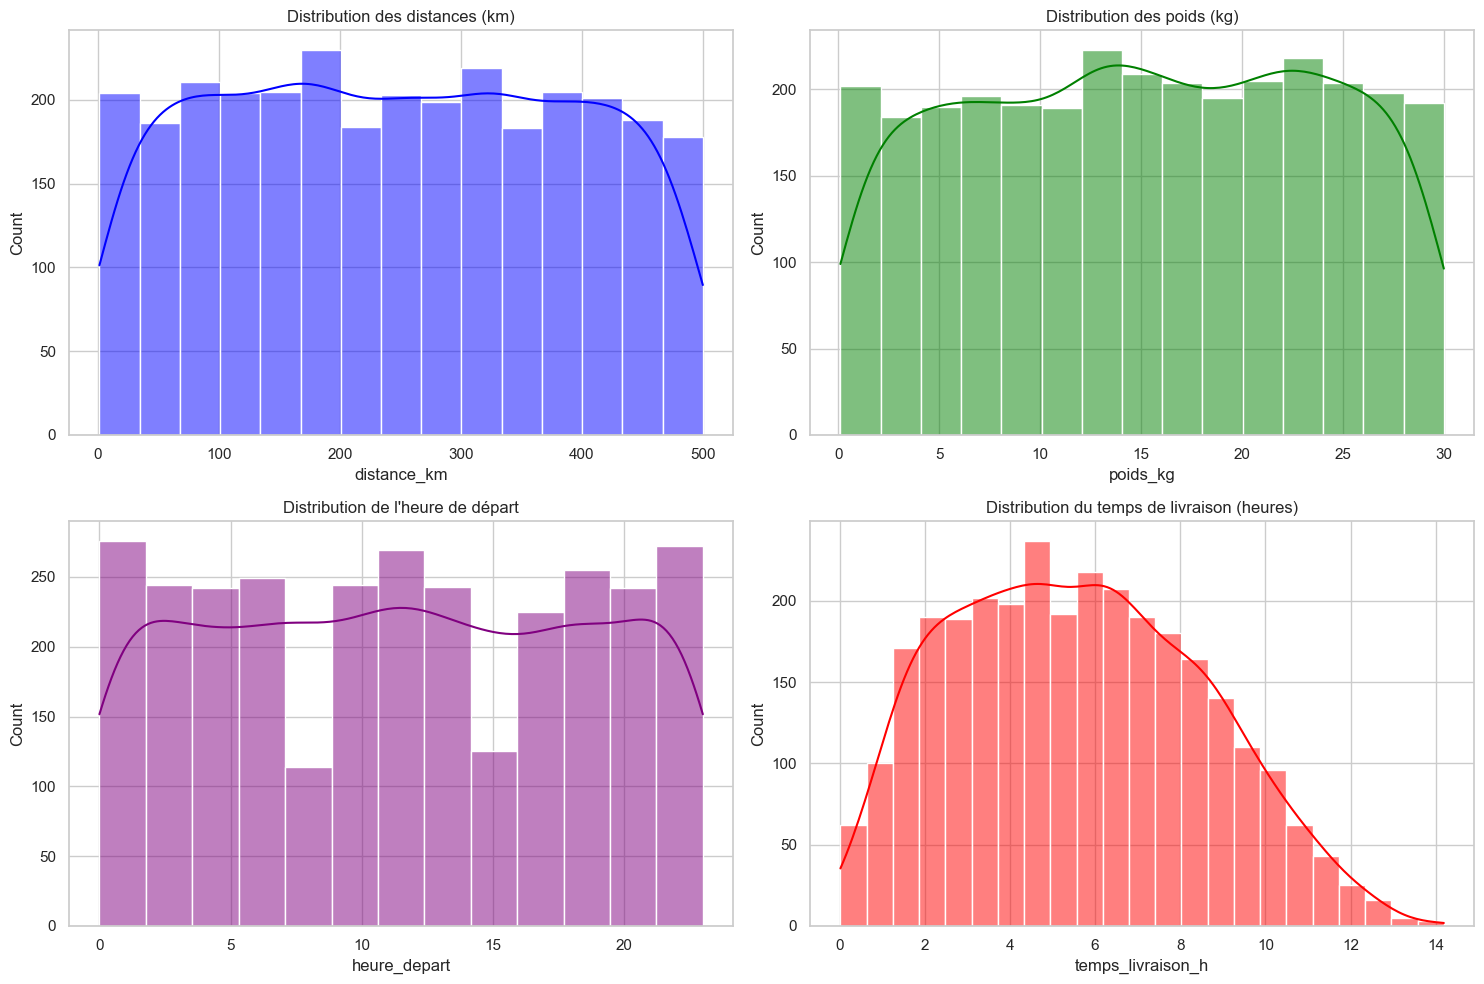

In [6]:
# Configuration de base pour avoir de jolis graphes
sns.set(style="whitegrid")
plt.figure(figsize=(15, 10))

# Distribution de distance
plt.subplot(2, 2, 1)
sns.histplot(df_imputed['distance_km'], kde=True, color="blue")
plt.title("Distribution des distances (km)")

# Distribution de poids
plt.subplot(2, 2, 2)
sns.histplot(df_imputed['poids_kg'], kde=True, color="green")
plt.title("Distribution des poids (kg)")

# Distribution de l'heure de départ
plt.subplot(2, 2, 3)
sns.histplot(df_imputed['heure_depart'], kde=True, color="purple")
plt.title("Distribution de l'heure de départ")

# Distribution du temps de livraison
plt.subplot(2, 2, 4)
sns.histplot(df_imputed['temps_livraison_h'], kde=True, color="red")
plt.title("Distribution du temps de livraison (heures)")

plt.tight_layout()
plt.show()


<br>

- ### <span style="color:blue"> Voir les relations entre toutes les variables </span>

<br>

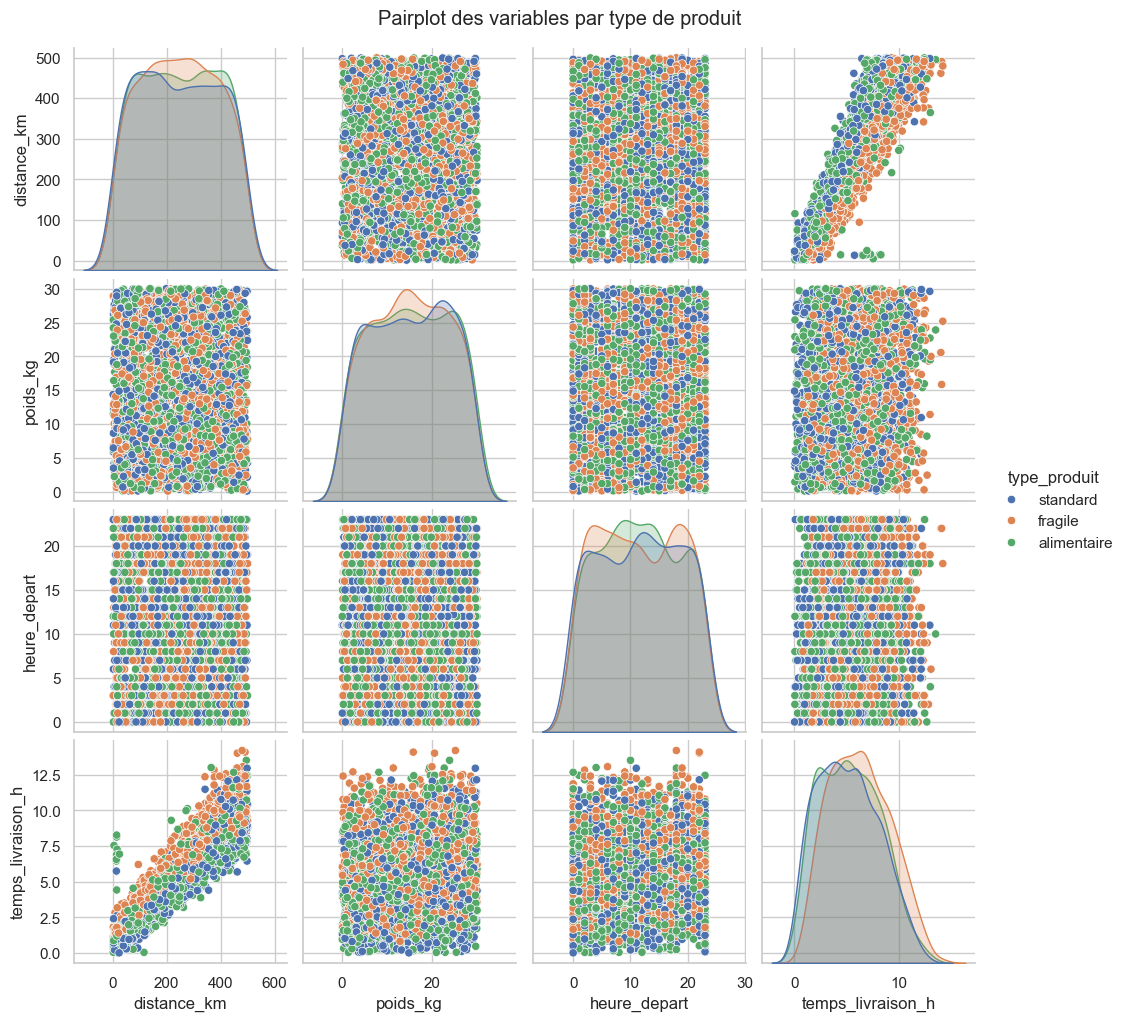

In [7]:
sns.pairplot(df_imputed, hue="type_produit")
plt.suptitle("Pairplot des variables par type de produit", y=1.02)
plt.show()


<br>

- ### <span style="color:blue"> Heatmap de la corrélation </span>

<br>

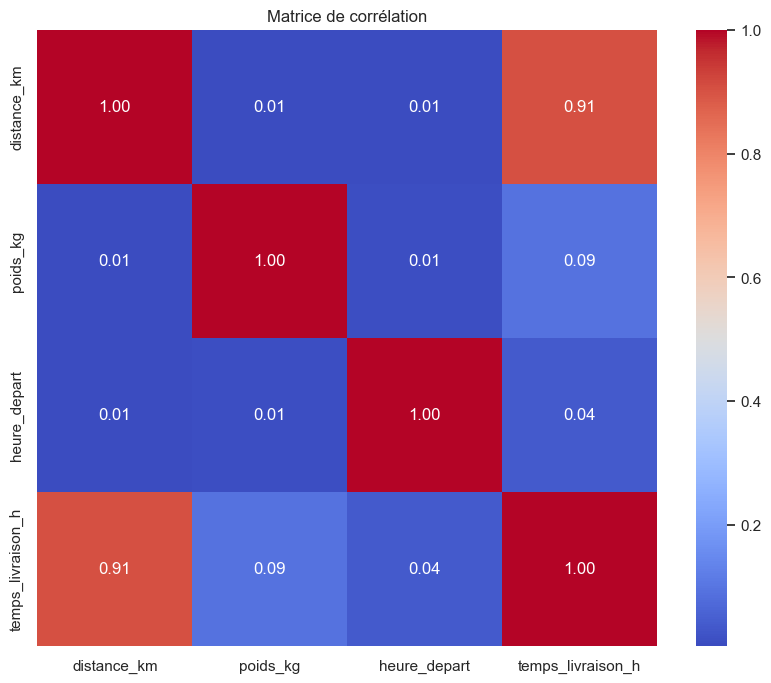

In [8]:
plt.figure(figsize=(10,8))
corr = df_imputed.select_dtypes(include=['float64']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matrice de corrélation")
plt.show()


<br> 

- ### <span style="color:blue"> afficher la liaison entre distance et temps livraison </span>

<br>

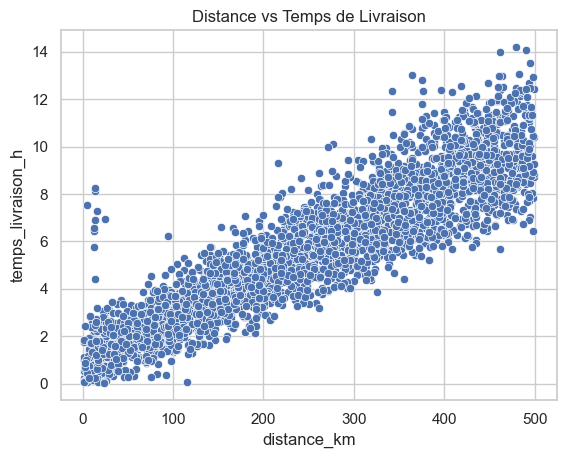

In [9]:
sns.scatterplot(x='distance_km', y='temps_livraison_h', data=df_imputed)
plt.title('Distance vs Temps de Livraison')
plt.show()


<br> 

- ### <span style="color:blue"> Préparation des données </span>

<br>

In [10]:
# Encodage du type_produit
df_encoded = pd.get_dummies(df_imputed, columns=['type_produit'], drop_first=True)


X = df_encoded.drop('temps_livraison_h', axis=1)
y = df_encoded['temps_livraison_h']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


<br> 

- ### <span style="color:blue"> Appliquer le modèle </span>

<br>

In [11]:
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

<br>

- ### <span style="color:blue"> Evaluation de modèle </span>

<br>

In [12]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAE : {mae:.2f}")
print(f"R2 score : {r2:.2f}")



MSE : 1.27
RMSE : 1.13
MAE : 0.84
R2 score : 0.85


<br>

- ### <span style="color:blue"> Visualisation des prédictions vs réalité </span>

<br>

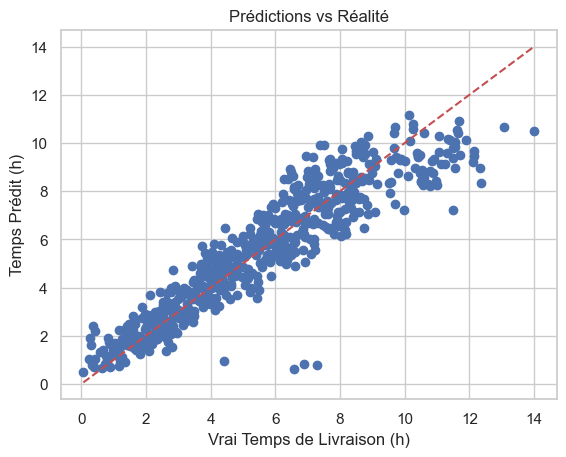

In [13]:
plt.scatter(y_test, y_pred)
plt.xlabel("Vrai Temps de Livraison (h)")
plt.ylabel("Temps Prédit (h)")
plt.title("Prédictions vs Réalité")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()


In [14]:
nouvelle_commande = pd.DataFrame({
    'distance_km': [120],
    'poids_kg': [5.2],
    'heure_depart': [20],
    'type_produit_fragile': [1],  # 1 si c'est fragile, sinon 0
    'type_produit_standard': [0], # 1 si c'est standard, sinon 0
    # Pas besoin d'ajouter 'alimentaire' car on a drop_first dans les dummies
})

# Prédiction
prediction = model.predict(nouvelle_commande)

print(f"Temps de livraison estimé : {prediction[0]:.2f} heures")


Temps de livraison estimé : 3.69 heures
